In [10]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import geopandas as gpd  # For geospatial data handling
import folium  # For creating interactive maps
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For statistical data visualization
from geopy.geocoders import Nominatim  # For geocoding
import time  # For pausing

In [11]:
# Load the Volontaire dataset
challenge_dataset_path = '/content/Challenge dataset.xlsx'  # Path to the Excel file
df_volontaire = pd.read_excel(challenge_dataset_path, sheet_name='Volontaire')

In [12]:
# Clean the Volontaire dataset
df_volontaire.dropna(subset=['Arrondissement_de_résidence_', 'Quartier_de_Résidence_'], inplace=True)
df_volontaire.rename(columns={
    'Arrondissement_de_résidence_': 'Arrondissement',
    'Quartier_de_Résidence_': 'Quartier'
}, inplace=True)

In [13]:
# Display unique Arrondissement responses
unique_arrondissements = df_volontaire['Arrondissement'].unique()
print("Unique Arrondissement Responses:")
for arrondissement in unique_arrondissements:
    print(arrondissement)

Unique Arrondissement Responses:
Douala 3
R A S
Douala 1
Douala 5
Douala (Non précisé )
Non précisé
Douala 2
Douala 4
Yaounde
Meiganga
R A S 
Edea
RAS 
OYACK
Ras
Manjo
Douala 6
Pas precise
TIKO
Pas précisé
Bafoussam
RAS
BOKO
Kribi
West
Njombe
Nkouabang
Ngodi Bakoko 
non precisé
Buea
Dschang
Bomono Ba Mbegue
BUEA
Douala
DCANKONGMONDO
LIMBE 
Pas précisé 
Deido
SUD OUEST TOMBEL
Pas mentionné
Yaoundé


In [15]:
# Initialize the Nominatim geocoder
geolocator = Nominatim(user_agent="myGeocoder")

# List of Arrondissements you want to geocode
arrondissements = df_volontaire['Arrondissement'].unique()

# Create a dictionary to hold coordinates
arrondissement_coords = {}

# Geocode each arrondissement
for town in arrondissements:
    try:
        location = geolocator.geocode(town + ', Cameroon', timeout=10)
        if location:
            arrondissement_coords[town] = (location.latitude, location.longitude)
        else:
            print(f"Could not geocode: {town}")
        # Pause for a short duration to avoid rate limiting
        time.sleep(1)
    except Exception as e:  # Catch all exceptions
        print(f"Geocoding error for {town}: {e}")
        time.sleep(5)

# Create a new DataFrame to hold coordinates
df_volontaire['Coordinates'] = df_volontaire['Arrondissement'].map(arrondissement_coords)

# Split the Coordinates into separate latitude and longitude columns
df_volontaire[['Latitude', 'Longitude']] = pd.DataFrame(df_volontaire['Coordinates'].tolist(), index=df_volontaire.index)

# Drop rows where coordinates are not available
df_volontaire.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Display updated DataFrame
print("\nVolontaire Dataset with Coordinates:")
print(df_volontaire[['Arrondissement', 'Latitude', 'Longitude']])


Volontaire Dataset with Coordinates:
     Arrondissement  Latitude  Longitude
0          Douala 3  4.028425   9.781926
1             R A S  4.010561   9.748672
2          Douala 1  3.861247   9.623577
3          Douala 5  4.135387   9.803438
8          Douala 2  4.016033   9.713089
...             ...       ...        ...
1838       Douala 4  4.078437   9.646548
1839       Douala 3  4.028425   9.781926
1840        Yaounde  3.868987  11.521334
1841       Douala 3  4.028425   9.781926
1845       Douala 3  4.028425   9.781926

[866 rows x 3 columns]


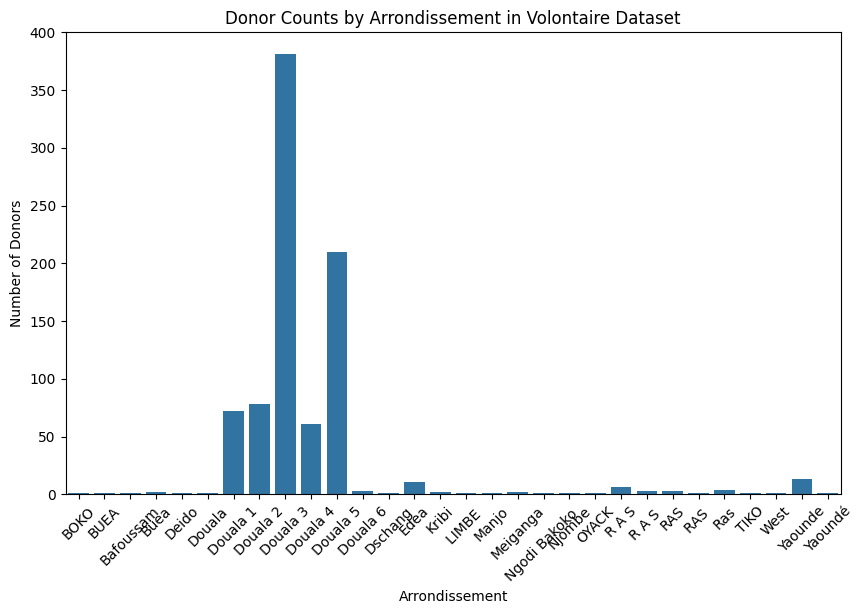

In [16]:
# Count donors by arrondissement
donor_counts = df_volontaire.groupby('Arrondissement').size().reset_index(name='Donor Count')

# Plotting the donor counts by arrondissement
plt.figure(figsize=(10, 6))
sns.barplot(data=donor_counts, x='Arrondissement', y='Donor Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.title('Donor Counts by Arrondissement in Volontaire Dataset')  # Title of the plot
plt.xlabel('Arrondissement')  # x-axis label
plt.ylabel('Number of Donors')  # y-axis label
plt.show()  # Display the plot

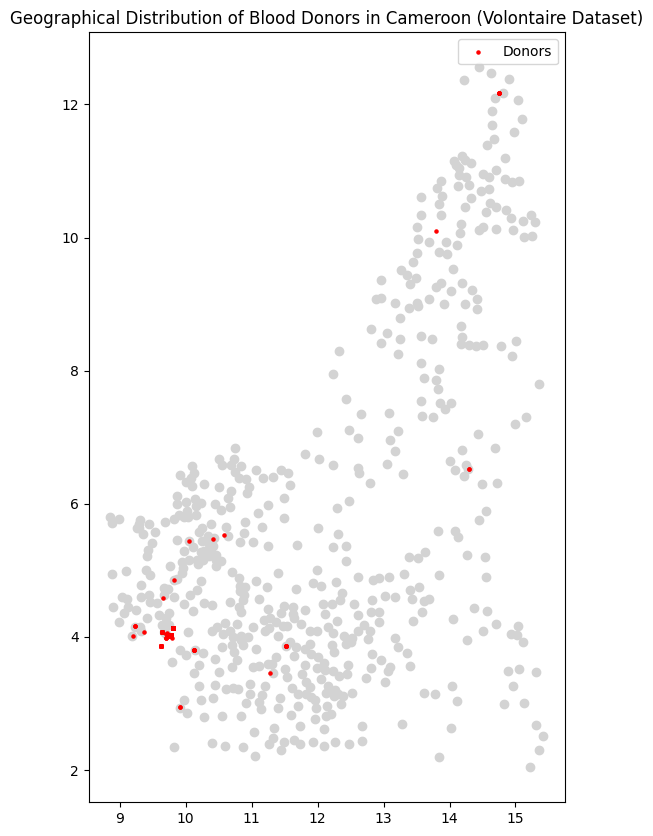

In [18]:
# Load the Cameroon map shapefile
cameroon_map = gpd.read_file('/content/cmr_cities.zip')

# Create a GeoDataFrame for donors based on their coordinates
donors_geo = gpd.GeoDataFrame(df_volontaire, geometry=gpd.points_from_xy(df_volontaire.Longitude, df_volontaire.Latitude))

# Set the coordinate reference system to match the Cameroon map
donors_geo.crs = cameroon_map.crs

# Plotting the map with donor locations
fig, ax = plt.subplots(figsize=(12, 10))  # Create a figure and axis
cameroon_map.plot(ax=ax, color='lightgrey')  # Plot the Cameroon map
donors_geo.plot(ax=ax, marker='o', color='red', markersize=5, label='Donors')  # Plot donor locations
plt.title('Geographical Distribution of Blood Donors in Cameroon (Volontaire Dataset)')  # Title of the map
plt.legend()  # Show legend
plt.show()  # Display the map

In [20]:
# Create an interactive map using Folium
m = folium.Map(location=[3.848, 11.5021], zoom_start=6)  # Center coordinates for the map

# Add donor locations to the map as circle markers
for idx, row in donors_geo.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),  # Latitude and longitude
        radius=5,  # Size of the circle marker
        color='blue',  # Marker color
        fill=True,
        fill_color='blue',  # Fill color
        fill_opacity=0.6,  # Fill opacity
        popup=f"Arrondissement: {row['Arrondissement']}<br>Quartier: {row['Quartier']}"  # Popup with arrondissement info
    ).add_to(m)  # Add the marker to the map

# Display the map in the notebook
m